# **Proyecto de Clusterización – Marketing Campaign Dataset**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/PYTHON_DATA/marketing_campaign.csv', sep='\t')

In [ ]:
dataset.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
dataset.shape

(2240, 29)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Este dataset contiene información de clientes y campañas de marketing.

# **EDA**

In [ ]:
dataset.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# **Imputación de valores nulos con mediana**

In [ ]:
dataset['Income'].describe()


,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
25%,35303.000000
50%,51381.500000
75%,68522.000000
max,666666.000000


In [ ]:
dataset['Income'].median()

51381.5

In [ ]:
dataset['Income'].fillna(dataset['Income'].median(), inplace=True)

/tmp/ipykernel_19799/984073219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Income'].fillna(dataset['Income'].median(), inplace=True)


In [ ]:
dataset['Income'].isna().sum()

np.int64(0)

# **Eliminación de duplicados**

In [ ]:
dataset.duplicated().sum()

np.int64(0)

# **Creación de nuevas variables**

In [ ]:
dataset['Edad']= 2026-dataset['Year_Birth']

In [ ]:
dataset['Total_Gastado'] = (
    dataset['MntWines'] +
    dataset['MntFruits'] +
    dataset['MntMeatProducts'] +
    dataset['MntFishProducts'] +
    dataset['MntSweetProducts'] +
    dataset['MntGoldProds']
)

In [ ]:
dataset['Total_Compras'] = (
    dataset['NumWebPurchases'] +
    dataset['NumCatalogPurchases'] +
    dataset['NumStorePurchases']
)

In [ ]:
dataset.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Edad,Total_Gastado,Total_Compras
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,69,1617,22
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,72,27,4
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,61,776,20
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,42,53,6
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,45,422,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,0,0,0,0,3,11,0,59,1341,16
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,1,0,0,3,11,0,80,444,15
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,0,0,0,0,3,11,0,45,1241,18
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,0,0,0,0,3,11,0,70,843,21


# **Análisis Univariado**

In [ ]:
variables_numericas = ['Income',
    'Edad',
    'Recency',
    'Total_Gastado',
    'Total_Compras']

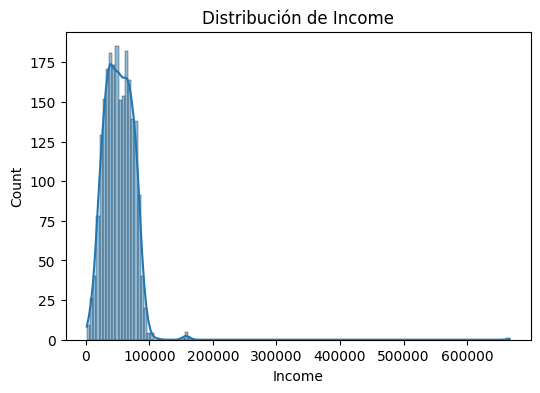

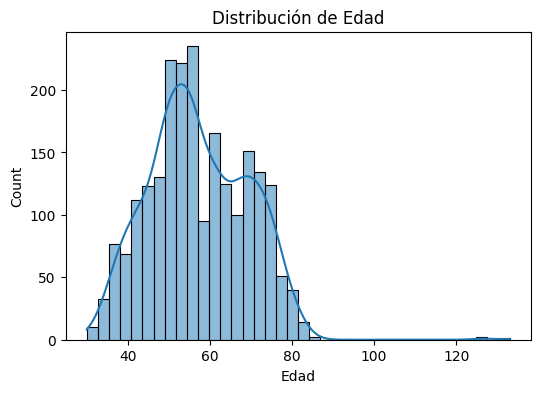

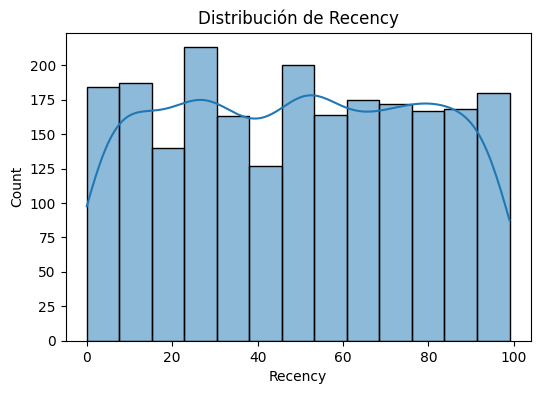

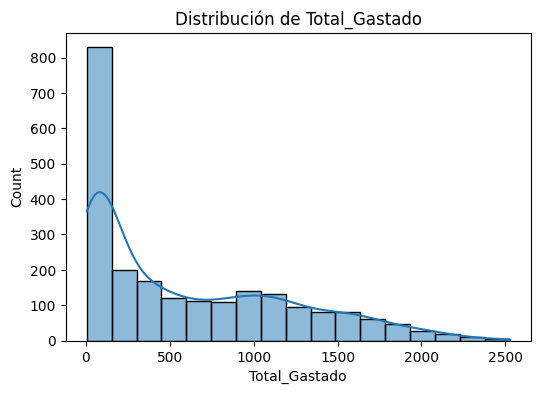

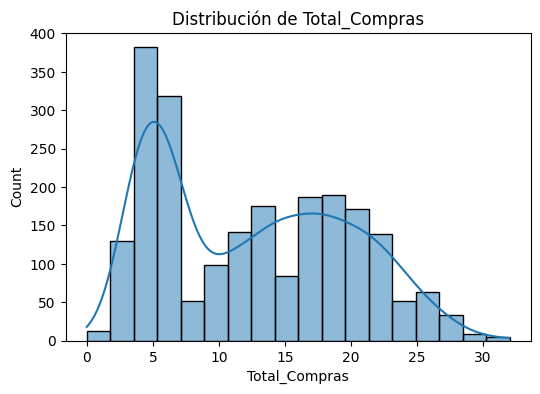

In [ ]:
for col in variables_numericas:
    plt.figure(figsize=(6,4))
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()

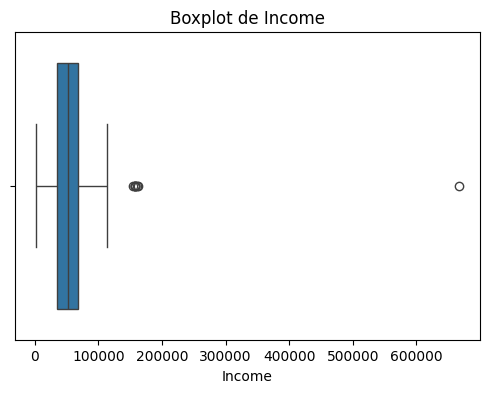

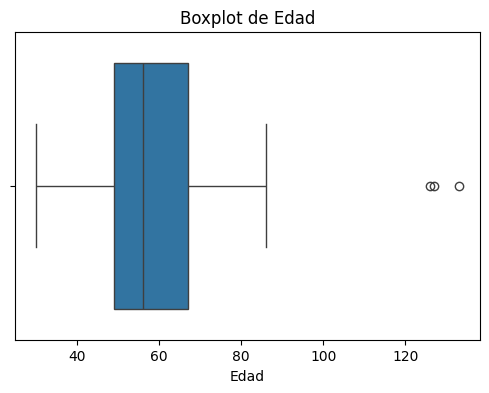

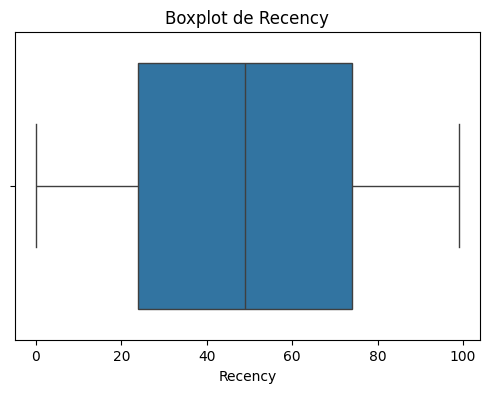

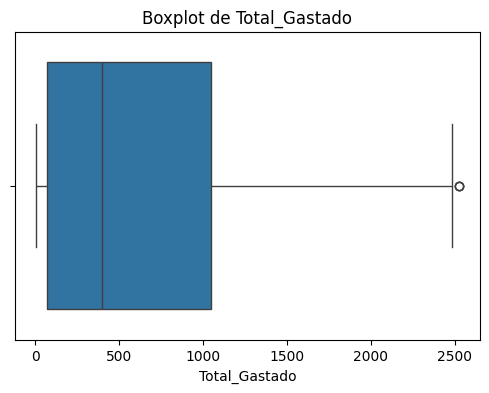

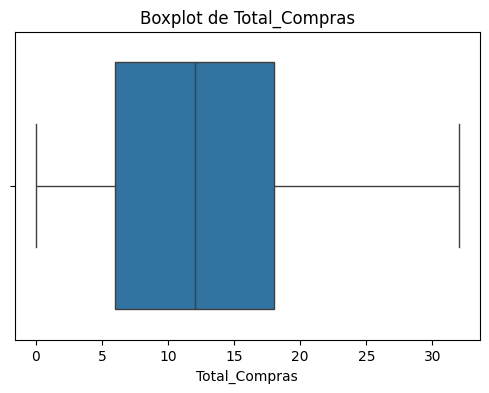

In [ ]:
for col in variables_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

In [ ]:
variables_categoricas = ['Education', 'Marital_Status']

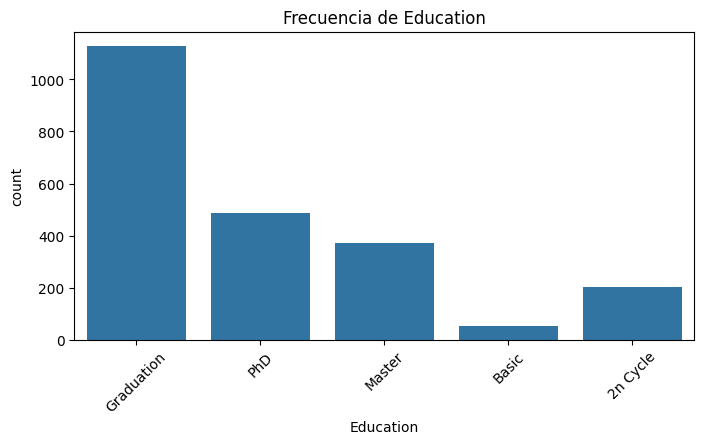

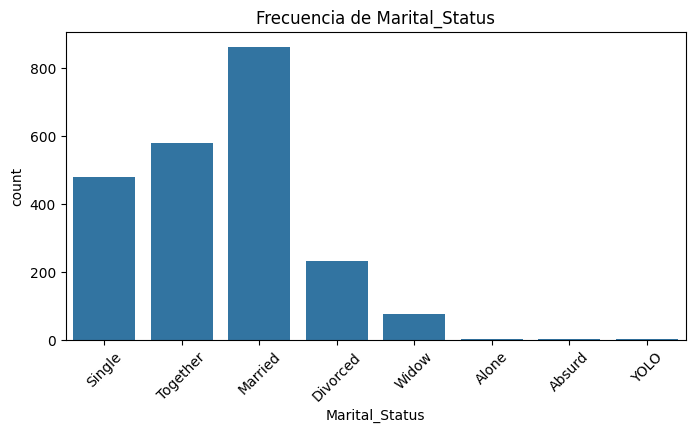

In [ ]:
for col in variables_categoricas:
    plt.figure(figsize=(8,4))
    sns.countplot(data=dataset, x=col)
    plt.xticks(rotation=45)
    plt.title(f'Frecuencia de {col}')
    plt.show()

# **Análisis Bivariado**

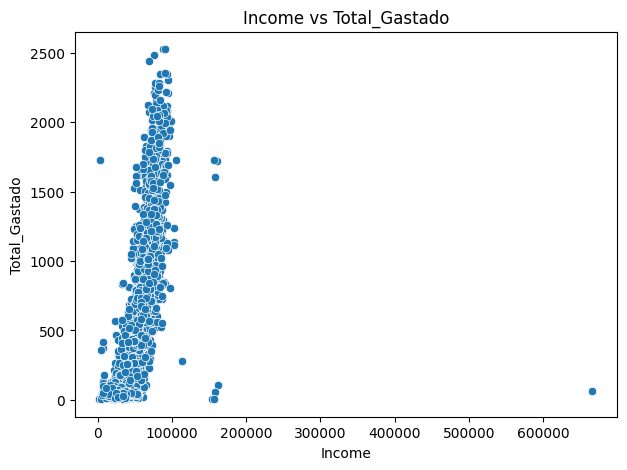

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=dataset, x='Income', y='Total_Gastado')
plt.title('Income vs Total_Gastado')
plt.show()

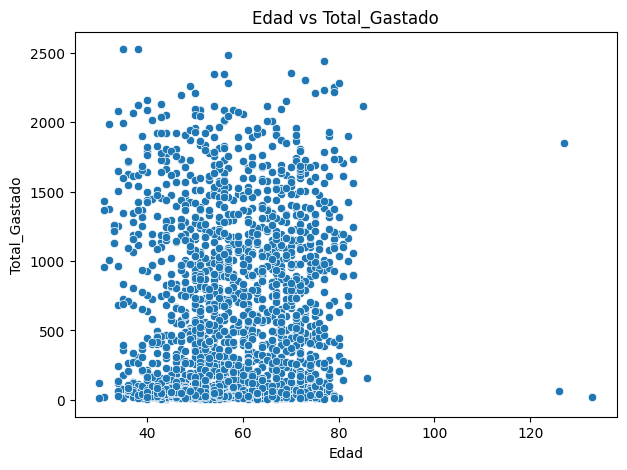

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=dataset, x='Edad', y='Total_Gastado')
plt.title('Edad vs Total_Gastado')
plt.show()

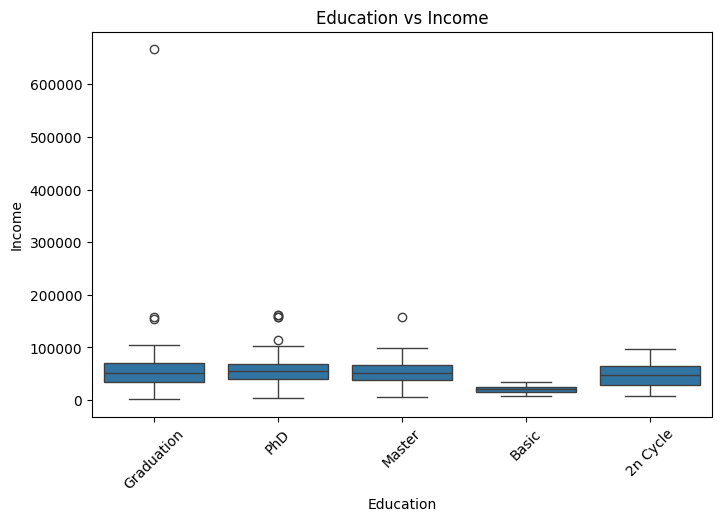

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=dataset, x='Education', y='Income')
plt.xticks(rotation=45)
plt.title('Education vs Income')
plt.show()

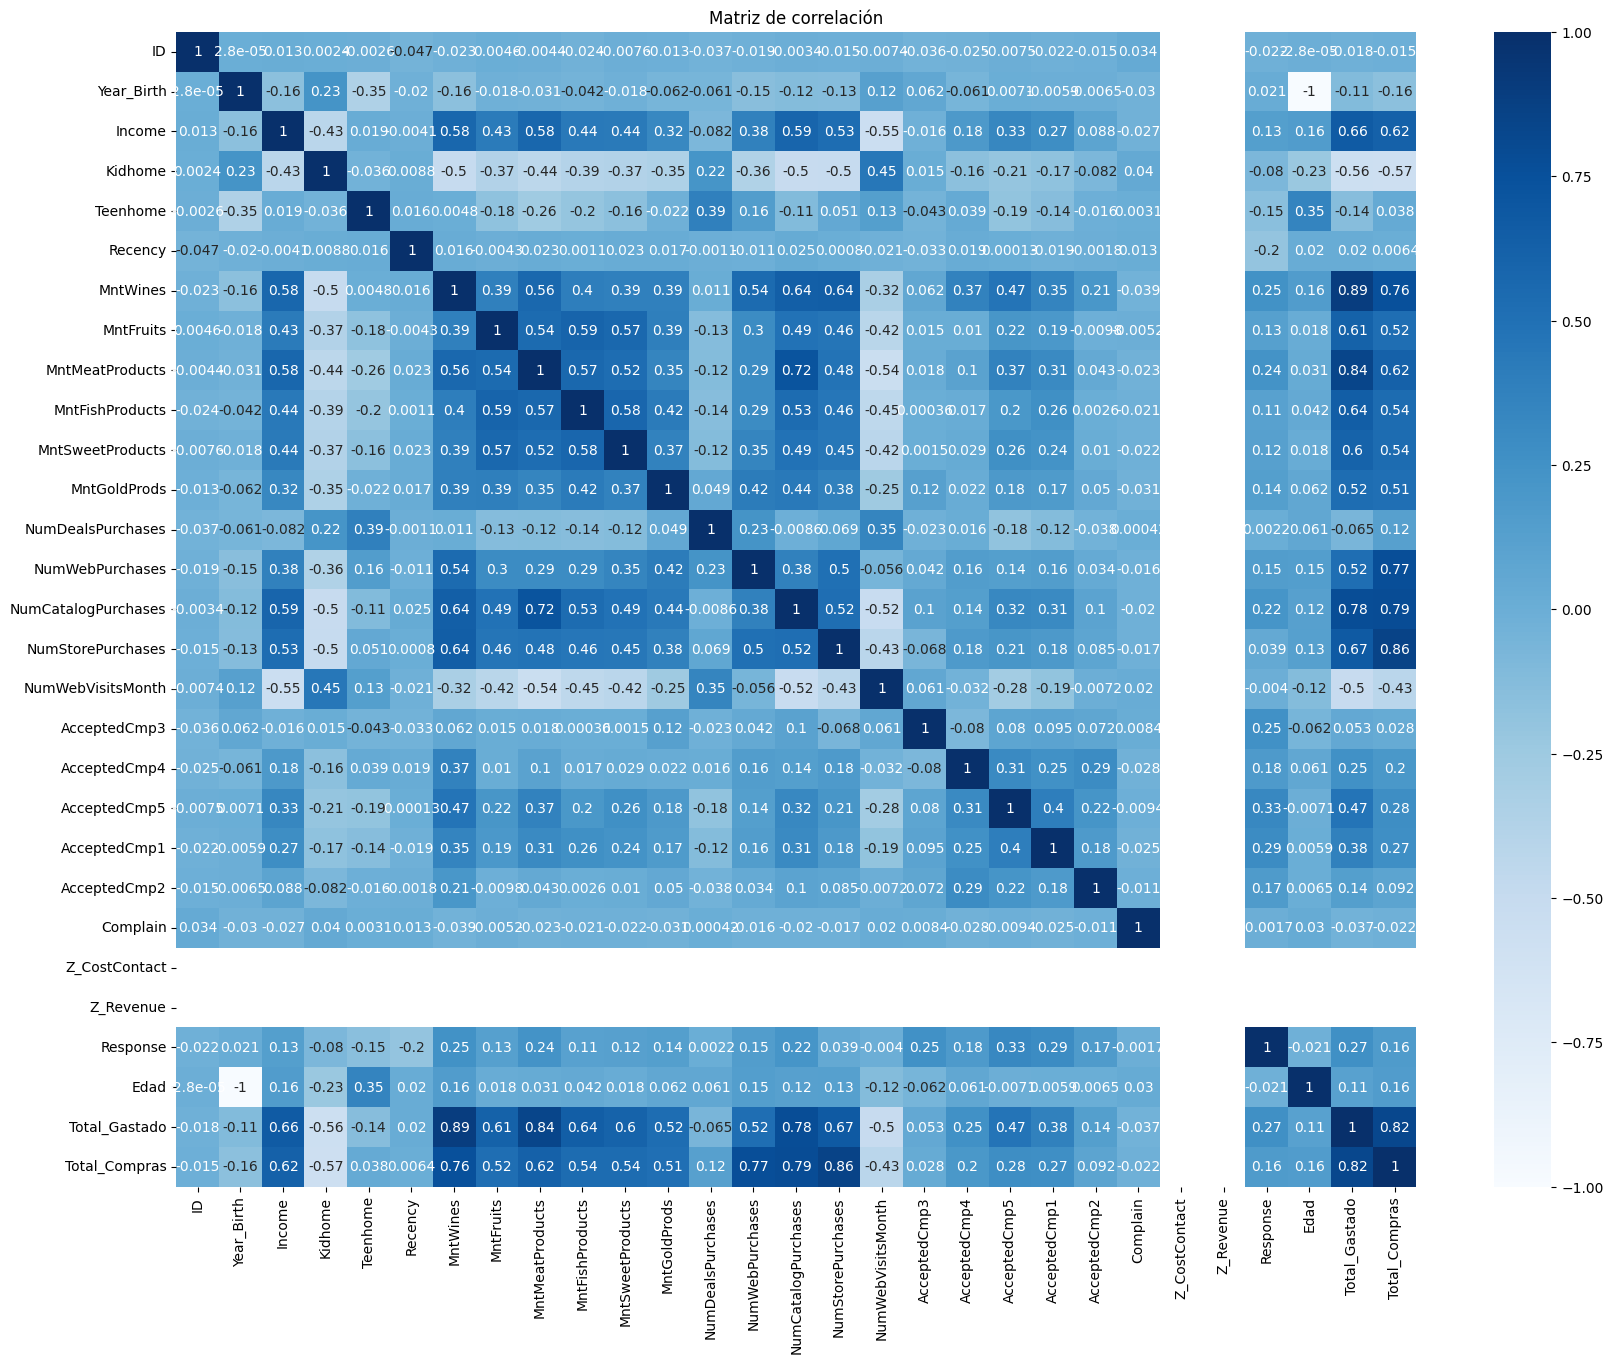

In [ ]:
plt.figure(figsize=(20,15))

sns.heatmap(
    dataset.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Matriz de correlación')
plt.show()

**Hallazgos bivariados**
- Existe relación positiva entre
Income y Total_Gastado.
- Los clientes con mayores ingresos realizan más compras.
- Algunos niveles educativos presentan mayores ingresos promedio.

# **Análisis Multivariado**

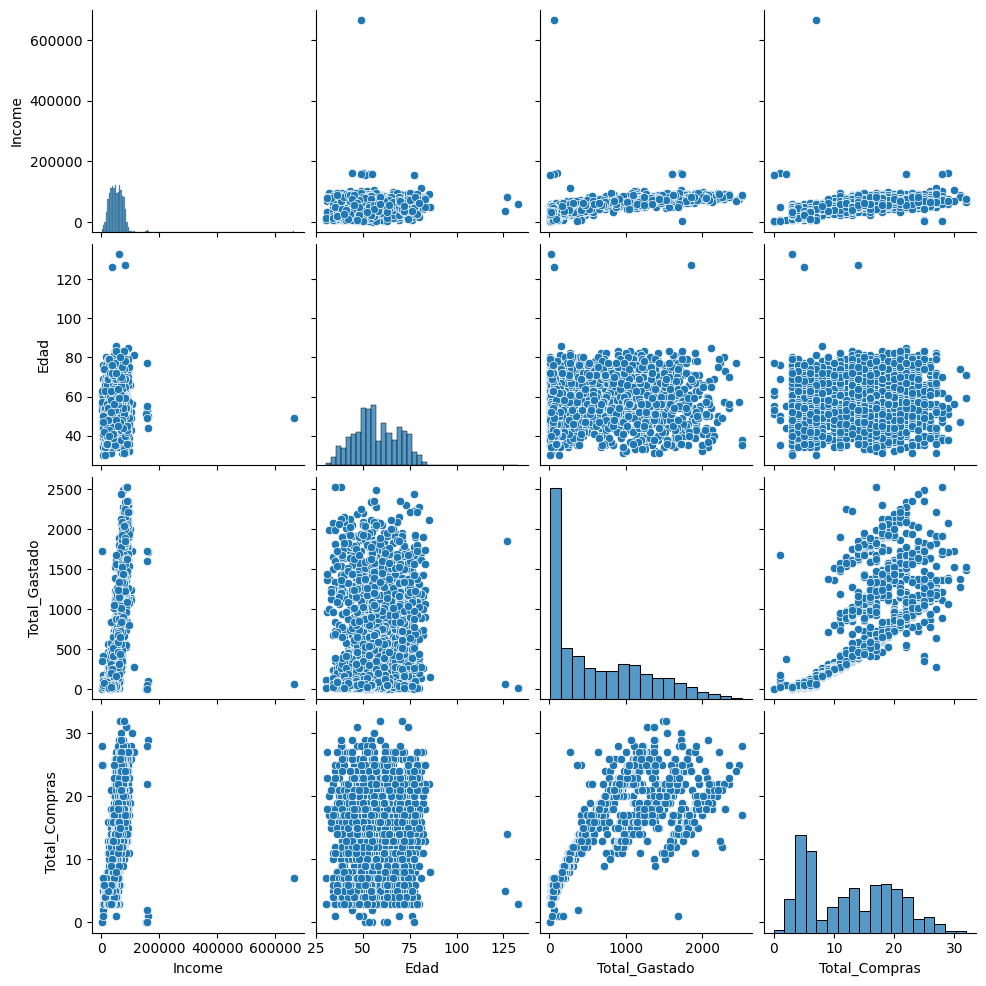

In [ ]:
sns.pairplot(
    dataset[[
        'Income',
        'Edad',
        'Total_Gastado',
        'Total_Compras'
    ]]
)

plt.show()

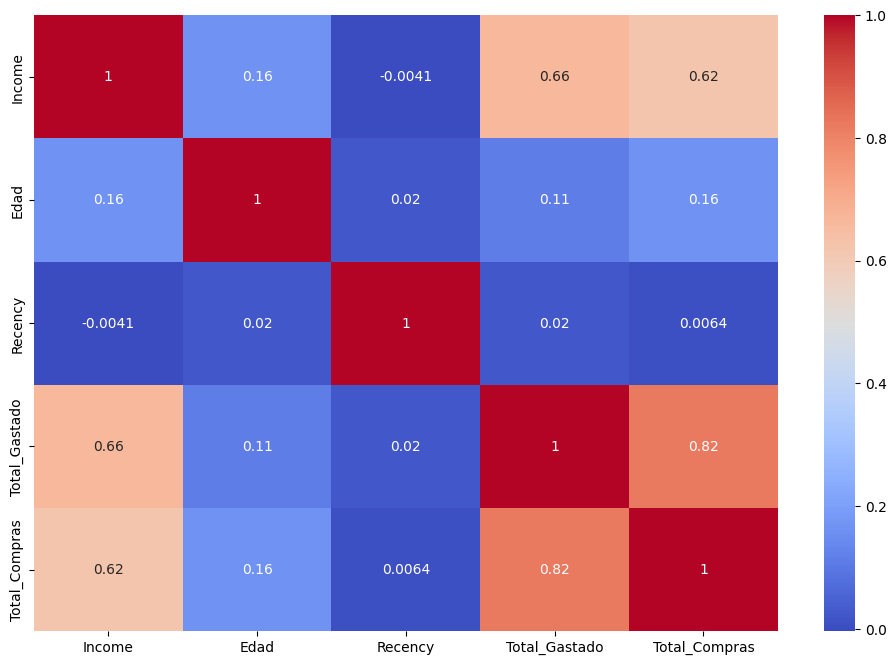

In [ ]:
plt.figure(figsize=(12,8))

corr = dataset[[
    'Income',
    'Edad',
    'Recency',
    'Total_Gastado',
    'Total_Compras'
]].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# **Hallazgos multivariados**
- Total_Gastado y Total_Compras presentan alta correlación.
- Los clientes con mayores ingresos tienden a comprar más productos.
- La edad presenta una relación débil con las compras.

# **Identificación y tratamiento de outliers**

In [ ]:
Q1 = dataset['Income'].quantile(0.25)
Q3 = dataset['Income'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

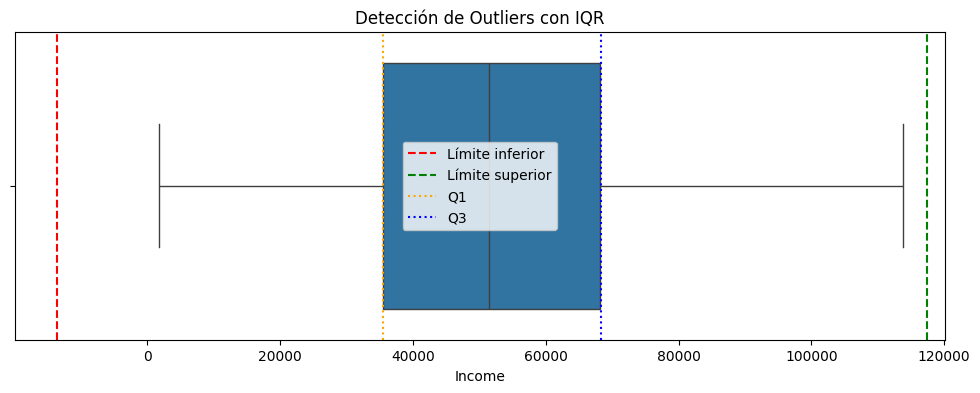

In [ ]:
plt.figure(figsize=(12,4))

sns.boxplot(x=dataset['Income'])

# Líneas de límites
plt.axvline(
    limite_inferior,
    color='red',
    linestyle='--',
    label='Límite inferior'
)

plt.axvline(
    limite_superior,
    color='green',
    linestyle='--',
    label='Límite superior'
)

# Línea Q1
plt.axvline(
    Q1,
    color='orange',
    linestyle=':',
    label='Q1'
)

# Línea Q3
plt.axvline(
    Q3,
    color='blue',
    linestyle=':',
    label='Q3'
)

plt.title('Detección de Outliers con IQR')
plt.legend()

plt.show()


In [ ]:

dataset = dataset[
    (dataset['Income'] >= limite_inferior) &
    (dataset['Income'] <= limite_superior)
]

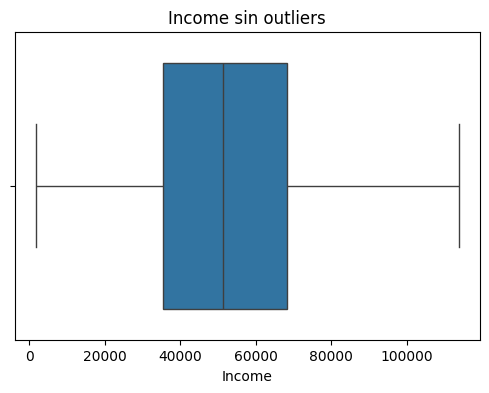

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=dataset['Income'])
plt.title('Income sin outliers')
plt.show()

# **Codificación de variables categóricas**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from sklearn.decomposition import PCA

In [ ]:
le = LabelEncoder()

columnas_cat = ['Education', 'Marital_Status']

for col in columnas_cat:
    dataset[col] = le.fit_transform(dataset[col])

/tmp/ipykernel_19799/4019402140.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[col] = le.fit_transform(dataset[col])
/tmp/ipykernel_19799/4019402140.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[col] = le.fit_transform(dataset[col])


In [ ]:
dataset.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Edad,Total_Gastado,Total_Compras
0,5524,1957,2,4,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,3,11,1,69,1617,22
1,2174,1954,2,4,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,3,11,0,72,27,4
2,4141,1965,2,5,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,3,11,0,61,776,20
3,6182,1984,2,5,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,3,11,0,42,53,6
4,5324,1981,4,3,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,3,11,0,45,422,14


In [ ]:
variables_cluster = [
    'Income',
    'Edad',
    'Total_Gastado',
    'Total_Compras',
    'Recency'
]

X = dataset[variables_cluster]

Las variables fueron seleccionadas porque representan:

- Capacidad económica
- Comportamiento de compra
- Frecuencia de consumo
- Perfil del cliente

# **Escalamiento de datos**

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
print(X_scaled)

[[ 0.31592236  0.9837257   1.68200203  1.31724801  0.30708091]
 [-0.25668352  1.23398319 -0.96222727 -1.18970396 -0.38385114]
 [ 0.97014182  0.3163724   0.28338766  1.03869779 -0.79841036]
 ...
 [ 0.2597493  -1.01833419  1.05670001  0.76014757  1.44711878]
 [ 0.85517397  1.06714486  0.39481116  1.1779729  -1.4202492 ]
 [ 0.0601092   1.23398319 -0.72108686 -0.63260352 -0.31475793]]


# **Método del codo**

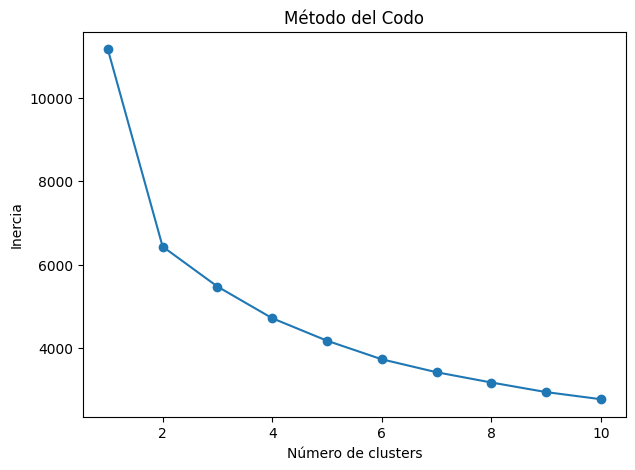

In [ ]:
inertia = []

for k in range(1,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inertia.append(modelo.inertia_)
plt.figure(figsize=(7,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

El valor óptimo de k se identifica donde la curva empieza a estabilizarse.

# **Modelo de Clusterización**

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [ ]:
dataset['Cluster'] = clusters

/tmp/ipykernel_19799/4026150116.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Cluster'] = clusters


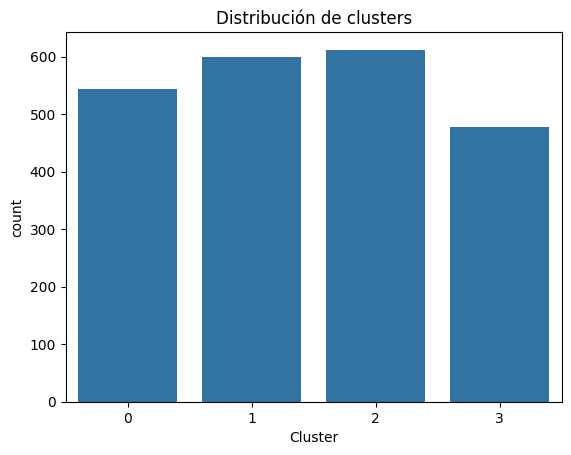

In [ ]:
sns.countplot(data=dataset, x='Cluster')
plt.title('Distribución de clusters')
plt.show()

In [ ]:
silhouette = silhouette_score(X_scaled, clusters)

print('Silhouette Score:', silhouette)

Silhouette Score: 0.2393377628240245


In [ ]:
db_score = davies_bouldin_score(X_scaled, clusters)

print('Davies-Bouldin Score:', db_score)

Davies-Bouldin Score: 1.5478655343495198


# **Interpretación**
- Silhouette cercano a 1 indica buena separación.
- Davies-Bouldin bajo indica clusters compactos.

# **PCA para visualización**

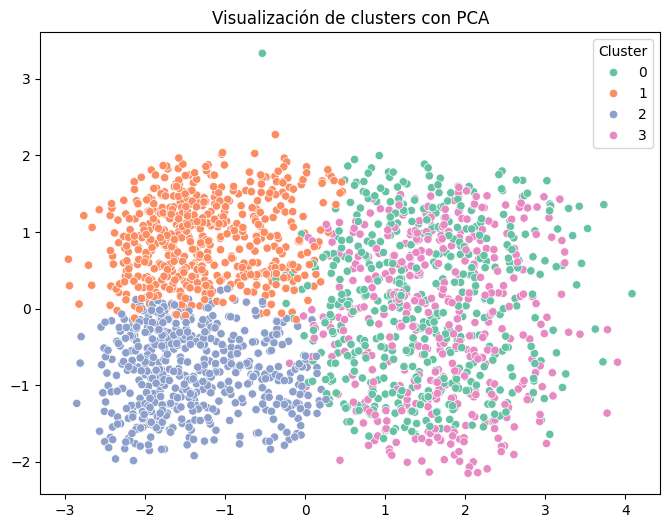

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=dataset['Cluster'],
    palette='Set2'
)

plt.title('Visualización de clusters con PCA')
plt.show()

PCA permite reducir dimensiones y visualizar los grupos encontrados.

# **Hallazgos del análisis univariado**
- La mayoría de clientes presenta ingresos medios.
- Existen outliers importantes en Income.
- El gasto total presenta alta variabilidad.
# **Hallazgos del análisis bivariado**
- Existe relación positiva entre Income y Total_Gastado.
- Clientes con mayores ingresos compran más productos.
- Algunos grupos educativos presentan mayores ingresos promedio.
# **Hallazgos del análisis multivariado**
- Total_Gastado y Total_Compras están altamente correlacionados.
- La edad tiene baja correlación con el gasto.
- Se identificaron patrones diferenciados de comportamiento.
# **Hallazgos del clustering**
- Se identificaron 4 segmentos de clientes.
- Algunos clusters representan clientes de alto valor.
- Otros clusters muestran bajo gasto y baja frecuencia de compra.
- El modelo logró separar adecuadamente los perfiles de clientes.
# **Conclusiones**
- El análisis exploratorio permitió comprender el comportamiento de los clientes.
- El preprocesamiento mejoró la calidad de los datos.
- El modelo KMeans logró identificar segmentos diferenciados.
- PCA facilitó la visualización de los clusters.
- Los resultados pueden ayudar a generar estrategias de marketing personalizadas.